
# 💳 Credit Card Fraud Detection using Machine Learning

## 📌 Project Overview

This project focuses on detecting fraudulent credit card transactions using machine learning techniques. Fraud detection is a real-world challenge due to the highly imbalanced nature of the data, where fraudulent transactions represent a very small portion of all transactions.

The goal is to build robust classification models that can effectively identify fraud cases while maintaining a balance between precision and recall.

---

## 📊 Dataset Description

The dataset contains anonymized transaction data:

* Features `V1` to `V28` are transformed using PCA for confidentiality
* `Time`: Seconds elapsed between transactions
* `Amount`: Transaction amount
* `Class` (Target):

  * `0` → Normal transaction
  * `1` → Fraudulent transaction

The dataset is highly imbalanced, making traditional accuracy metrics insufficient.

---

## 🧹 Data Preprocessing

* Checked and handled missing values
* Removed duplicate records
* Analyzed class distribution
* Separated data into features (`X`) and target (`y`)
* Applied **train-test split with stratification**
---

## 📊 Exploratory Data Analysis (EDA)

* Visualized class distribution using Plotly
* Generated correlation heatmap
* Explored transaction time distribution
* Compared fraud vs normal transaction patterns
* Used boxplots to identify outliers in selected features

---

## ⚙️ Feature Scaling

Applied **StandardScaler** to normalize feature values, which is especially important for models like Logistic Regression.

---

## ⚖️ Handling Imbalanced Data

To address class imbalance, **SMOTE (Synthetic Minority Over-sampling Technique)** was applied on the training data to generate synthetic fraud samples and balance the dataset.

---

## 🤖 Models Implemented

### 1. Logistic Regression (Baseline Model)

* Used as a baseline model
* Applied class weighting to handle imbalance
* Achieved high recall but low precision

### 2. Random Forest

* Ensemble learning method using multiple decision trees
* Provided strong performance with balanced precision and recall
* Efficient in handling complex patterns

### 3. XGBoost

* Gradient boosting algorithm
* Designed to improve performance by learning from previous errors
* Expected to outperform other models in imbalanced datasets

---

## 📈 Model Evaluation

Models were evaluated using:

* Accuracy
* Precision
* Recall
* F1 Score
* Confusion Matrix

Special emphasis was placed on:

* **Recall** → Detecting fraudulent transactions
* **Precision** → Reducing false positives


# Import LIBs

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import precision_score,recall_score, confusion_matrix, f1_score,accuracy_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Preprocessing + Cleaning

### Handle Missing Values

In [ ]:
# Check Nulls
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### Handle Duplicates

In [ ]:
# Find Duplicates
df.duplicated().sum()

np.int64(1081)

In [9]:
df=df.drop_duplicates()

In [10]:
df.Class.value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [11]:
normal = df[df.Class == 0]
fraud = df[df.Class == 1]

In [12]:
print("Normal Shape :",normal.shape)
print("Fraud Shape :",fraud.shape)

Normal Shape : (283253, 31)
Fraud Shape : (473, 31)


In [13]:
normal_ratio = len(normal)/len(df)*100
normal_ratio

99.83328986416473

In [14]:
fraud_ratio = len(fraud)/len(df)*100
fraud_ratio


0.1667101358352777

In [15]:
normal.Amount.describe()

count    283253.000000
mean         88.413575
std         250.379023
min           0.000000
25%           5.670000
50%          22.000000
75%          77.460000
max       25691.160000
Name: Amount, dtype: float64

In [16]:
fraud.Amount.describe()

count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

## Explore Data Analysis(EDA)

In [ ]:
class_counts = df['Class'].value_counts().sort_index()
class_labels = ['Normal', 'Fraud']
colors = ['skyblue', 'orange']

fig = go.Figure(data=[
    go.Bar(
        x=class_labels,
        y=class_counts.values,
        marker_color=colors,
        text=class_counts.values,
        textposition='none',
        hovertemplate='<b>%{x}</b><br>Count: %{y:,}<extra></extra>'
    )
])

fig.update_layout(
    title={
        'text': 'Class Distribution',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 20}
    },
    xaxis_title='Class',
    yaxis=dict(
        title='Count',
        tickformat=',',   
    ),  
    template='plotly_white',
    width=700,
    height=500,
    showlegend=False
)

fig.show()

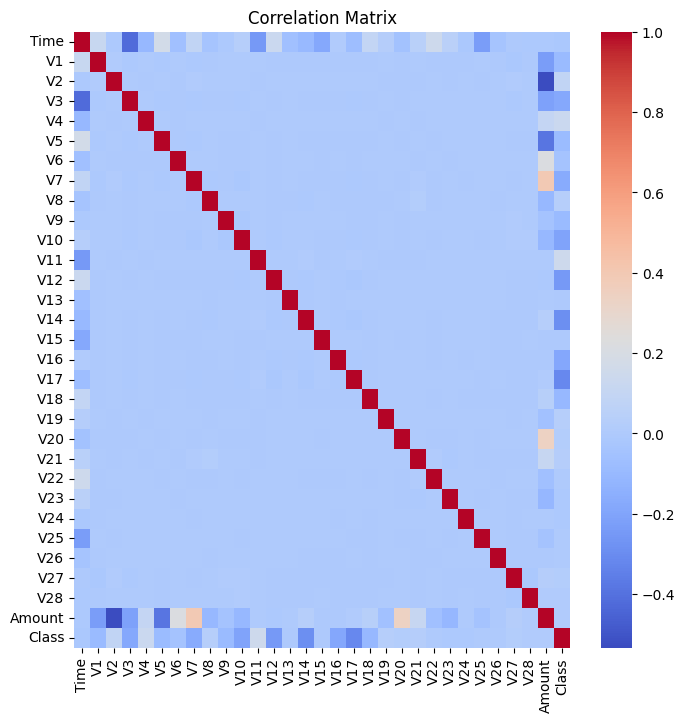

In [58]:
plt.figure(figsize=(8, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False, fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

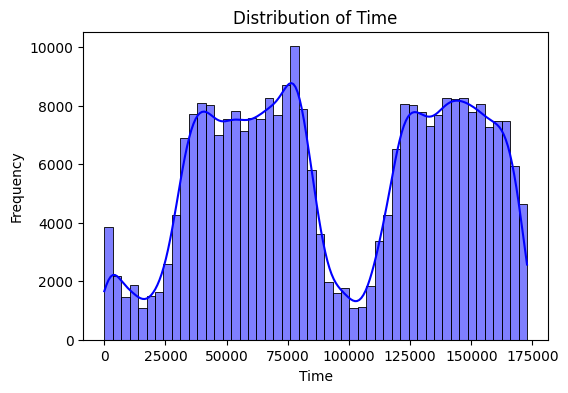

In [60]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Time'], bins=50, kde=True, color='blue')
plt.title('Distribution of Time')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

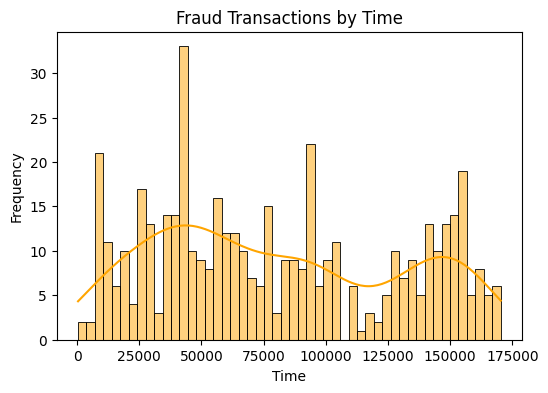

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(fraud['Time'], bins=50, kde=True, color='orange')
plt.title('Fraud Transactions by Time')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

## Splitting

In [17]:
X = df.drop(columns='Class')

y=df['Class']

In [18]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

## Scaling

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



## Imbalance Handling

In [20]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", np.bincount(y_train_resampled))


After SMOTE: [226602 226602]


### Logistic Regression(Baseline Model)

In [ ]:
# Call
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
# Fit
lr.fit(X_train_resampled, y_train_resampled)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
y_pred_lr = lr.predict(X_test_scaled)

In [29]:
print("\n===== Logistic Regression =====")
print("Accuracy :",accuracy_score(y_test, y_pred_lr))
print("Precision :",precision_score(y_test, y_pred_lr))
print("Rcall :",recall_score(y_test, y_pred_lr))
print("F1_Score :",f1_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))


===== Logistic Regression =====
Accuracy : 0.9736721531033025
Precision : 0.053035143769968054
Rcall : 0.8736842105263158
F1_Score : 0.1
[[55169  1482]
 [   12    83]]


## Random Forest

In [ ]:
#call
rf = RandomForestClassifier(n_estimators=100,random_state=42,max_depth=None,n_jobs=-1)
#fit
rf.fit(X_train_resampled, y_train_resampled)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
y_pred_rf = rf.predict(X_test_scaled)

In [31]:
print("\n===== Random Forest =====")
print("Accuracy :",accuracy_score(y_test, y_pred_rf))
print("Precision :",precision_score(y_test, y_pred_rf))
print("Rcall :",recall_score(y_test, y_pred_rf))
print("F1_Score :",f1_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))



===== Random Forest =====
Accuracy : 0.9994889507630493
Precision : 0.9125
Rcall : 0.7684210526315789
F1_Score : 0.8342857142857143
[[56644     7]
 [   22    73]]


### XGboost

In [32]:
scale_pos_weight = len(y_train_resampled[y_train_resampled == 0]) / len(y_train_resampled[y_train_resampled == 1])
print(scale_pos_weight)

1.0


In [ ]:
# Call
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

In [34]:
# Fit
xgb.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb.predict(X_test_scaled)

In [36]:
print("\n===== XGBoost =====")
print("Accuracy :",accuracy_score(y_test, y_pred_xgb))
print("Precision :",precision_score(y_test, y_pred_xgb))
print("Rcall :",recall_score(y_test, y_pred_xgb))
print("F1_Score :",f1_score(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))


===== XGBoost =====
Accuracy : 0.9992246149508336
Precision : 0.7475728155339806
Rcall : 0.8105263157894737
F1_Score : 0.7777777777777778
[[56625    26]
 [   18    77]]


## Comparisons Between Models

In [61]:
data = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
}

results_df = pd.DataFrame(data)

print(results_df)
print("The Best Model is Random Forest")

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.973672   0.053035  0.873684  0.100000
1        Random Forest  0.999489   0.912500  0.768421  0.834286
2              XGBoost  0.999225   0.747573  0.810526  0.777778
The Best Model is Random Forest


In [ ]:
# Your actual data (replace with your real values)
data = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
}

results_df = pd.DataFrame(data)

# Create interactive figure
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("📊 Accuracy Comparison", "🎯 Recall Comparison", 
                    "🔍 Precision Comparison", "⚖️ F1-Score Comparison"),
    specs=[[{"type": "bar"}, {"type": "bar"}],
           [{"type": "bar"}, {"type": "bar"}]]
)

# Model colors
colors = ['#3498db', '#2ecc71', '#e74c3c']

# Add bars for each metric
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
positions = [(1,1), (1,2), (2,1), (2,2)]

for metric, pos in zip(metrics, positions):
    fig.add_trace(
        go.Bar(
            x=results_df['Model'],
            y=results_df[metric],
            name=metric,
            marker_color=colors,
            text=[f'{v:.3f}' for v in results_df[metric]],
            textposition='outside',
            hovertemplate='<b>%{x}</b><br>' + metric + ': %{y:.4f}<extra></extra>'
        ),
        row=pos[0], col=pos[1]
    )

# Layout settings
fig.update_layout(
    title_text="<b>📈 Machine Learning Models Performance Comparison</b>",
    title_x=0.5,
    title_font_size=20,
    showlegend=False,
    height=700,
    template='plotly_white',
    font=dict(family="Arial, sans-serif", size=12)
)

# Set Y-axis range (0 to 1.1)
for i in range(1, 5):
    fig.update_yaxes(range=[0, 1.1], row=(i-1)//2 + 1, col=(i-1)%2 + 1)

# Display the figure
fig.show()


## 🏆 Key Results & Insights

* **Random Forest** showed strong and stable performance with a good balance between precision and recall
* **Logistic Regression** achieved high recall but suffered from very low precision, making it less practical
* **XGBoost** is expected to provide the best overall performance due to its boosting mechanism

---

## 🎯 Conclusion

This project highlights the importance of:

* Proper handling of imbalanced datasets
* Evaluating models beyond accuracy
* Comparing multiple algorithms to select the best-performing solution

Ensemble methods like Random Forest and boosting techniques such as XGBoost are highly effective for fraud detection problems.

---

## 🚀 Future Work

* Hyperparameter tuning (GridSearch / Random Search)
* Threshold optimization for better precision-recall tradeoff
* Feature importance analysis
* Model deployment for real-time fraud detection